# 온라인 제품 판매량 예측 모델 (Advanced Sales Prediction)

본 노트북은 과거 제품 판매 데이터와 브랜드 검색량을 분석하고, 이를 기반으로 향후 판매량을 예측하는 모델링 프로젝트입니다.

## 1. 데이터셋 컬럼별 설명

### train.csv
- **ID**: 제품별 고유 식별자
- **제품**: 제품 코드
- **대분류/중분류/소분류**: 제품 계층 구조

|**단계**|**명칭**|**예시 (가전)**|**예시 (식품)**|**특징**|
|---|---|---|---|---|
|**대분류**|`C001`|**주방가전**|**가공식품**|가장 큰 산업군 또는 제품군|
|**중분류**|`C002`|전자레인지|라면/면류|대분류를 용도별로 쪼갠 것|
|**소분류**|`C003`|복합오븐레인지|컵라면|실제 구매하는 구체적 품목|

- **브랜드**: 제품의 브랜드 정보
- **2022-01-01 ~ 2023-04-04**: 일별 판매량

### brand_keyword_cnt.csv
- **브랜드**: 브랜드 정보
- **2022-01-01 ~ 2023-04-04**: 일별 해당 브랜드의 검색 빈도 (정규화됨)

### product_info.csv
- **제품**: 제품 코드
- **제품특성**: 제품의 상세 스펙/설명 (텍스트 데이터)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import ccf, adfuller
import warnings

warnings.filterwarnings('ignore')
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

## 2. 데이터 로드 및 초기 탐색

In [2]:
train = pd.read_csv('./data/train.csv')
brand_keyword = pd.read_csv('./data/brand_keyword_cnt.csv')
product_info = pd.read_csv('./data/product_info.csv')
sales = pd.read_csv('./data/sales.csv')

print(f"Train Data: {train.shape}")
print(f"brand_keyword Data: {brand_keyword.shape}")
print(f"Product Info: {product_info.shape}")
display(train.head(3))

Train Data: (15890, 465)
brand_keyword Data: (3170, 460)
Product Info: (12778, 2)


,ID,제품,대분류,중분류,소분류,브랜드,2022-01-01,2022-01-02,2022-01-03,2022-01-04,...,2023-03-26,2023-03-27,2023-03-28,2023-03-29,2023-03-30,2023-03-31,2023-04-01,2023-04-02,2023-04-03,2023-04-04
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,1,3,2,0,0,2,0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
diff_cols = set(sales.columns) - set(train.columns)
print(f"sales.csv에만 있는 컬럼: {diff_cols}")
print(f"Train: {train.shape} / Sales: {sales.shape}")

sales.csv에만 있는 컬럼: set()
Train: (15890, 465) / Sales: (15890, 465)


train.csv와 sales.csv는 동일한 데이터임을 확인할 수 있습니다.

## 3. 탐색적 데이터 분석 (EDA)

### 3.1 제품 분포

In [4]:
train['대분류'].value_counts()

대분류
B002-C001-0002    10954
B002-C001-0001     3768
B002-C001-0005      613
B002-C001-0003      444
B002-C001-0004      111
Name: count, dtype: int64

전체 제품은 총 5개의 대분류로 구성되어 있으며, 카테고리별 제품 수 차이가 매우 큽니다.<br> 특히 B002-C001-0002 대분류가 10,954개로 전체 제품(15,890개)의 약 69%를 차지하는 압도적인 주력 카테고리임을 확인했습니다.

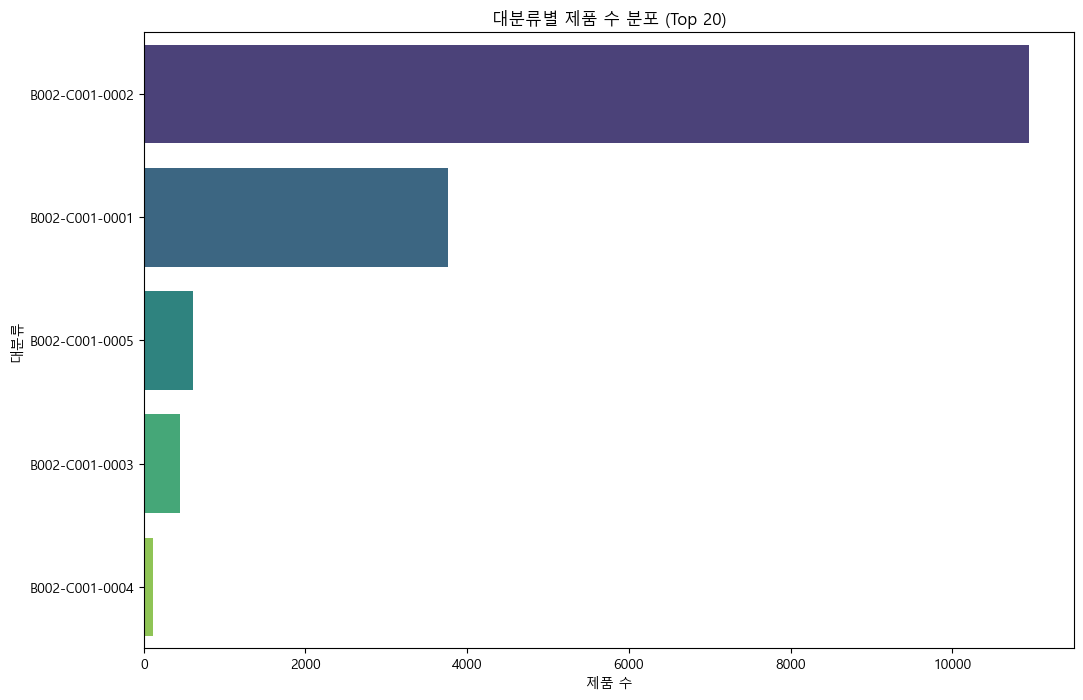

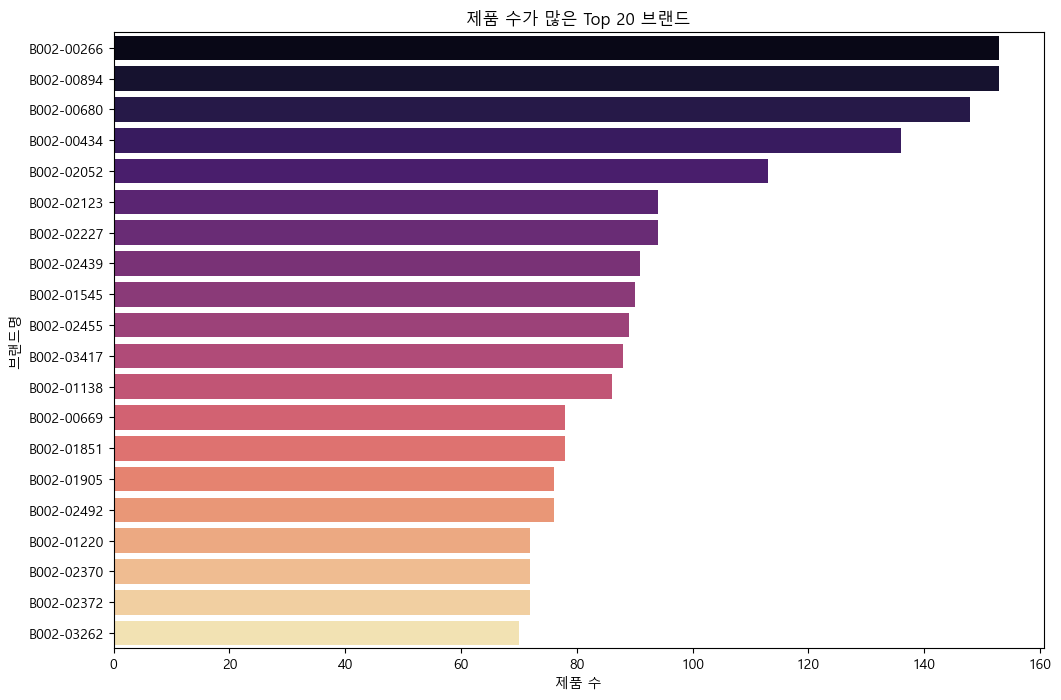

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 대분류별 제품 수 분포 시각화
plt.figure(figsize=(12, 8)) 
sns.countplot(data=train, y='대분류', order=train['대분류'].value_counts().index[:20], palette='viridis')
plt.title('대분류별 제품 수 분포 (Top 20)')
plt.xlabel('제품 수')
plt.ylabel('대분류')
plt.show()

# 제품 수가 많은 Top 20 브랜드
top_20_brands = train['브랜드'].value_counts().head(20)
plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_brands.values, y=top_20_brands.index, palette='magma')
plt.title('제품 수가 많은 Top 20 브랜드')
plt.xlabel('제품 수')
plt.ylabel('브랜드명')
plt.show()

### 3.2 제품 판매량

In [6]:
# '20'으로 시작하는 실제 날짜 컬럼들만 리스트로 뽑습니다.
only_date_cols = [c for c in train.columns if str(c).startswith('20')]

# 각 제품별로 전체 기간의 판매량 합계 계산
train['total_sum'] = train[only_date_cols].sum(axis=1)

# 대분류별로 전체 판매량 합산
cat_total_sales = train.groupby('대분류')['total_sum'].sum()

# 판매 점유율(%) 계산
cat_sales_ratio = (cat_total_sales / cat_total_sales.sum()) * 100

# 제품당 평균 판매량 계산
cat_avg_sales = train.groupby('대분류')['total_sum'].mean()

# 결과 데이터프레임 생성
summary_df = pd.DataFrame({
    '전체 판매량 합계': cat_total_sales.astype(int),
    '판매 점유율(%)': cat_sales_ratio.round(2),
    '제품당 평균 판매량': cat_avg_sales.round(2)
}).sort_values(by='전체 판매량 합계', ascending=False)

print("--- 대분류별 판매 기여도 분석 ---")
print(summary_df)

--- 대분류별 판매 기여도 분석 ---
                전체 판매량 합계  판매 점유율(%)  제품당 평균 판매량
대분류                                             
B002-C001-0002   87218401      67.72     7962.24
B002-C001-0001   35441662      27.52     9405.96
B002-C001-0005    4961560       3.85     8093.90
B002-C001-0003    1078827       0.84     2429.79
B002-C001-0004      85411       0.07      769.47


월별 판매량

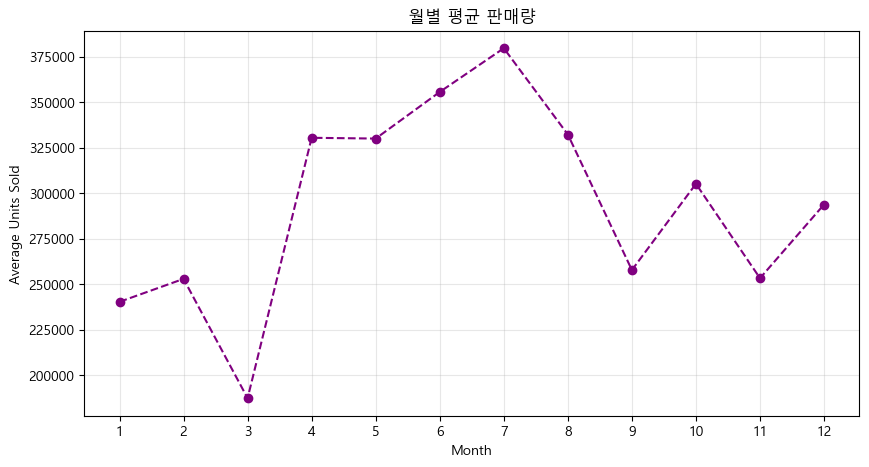

In [7]:
daily_total_sales = train[only_date_cols].sum(axis=0)
daily_total_sales.index = pd.to_datetime(daily_total_sales.index)
monthly_sales = daily_total_sales.groupby(daily_total_sales.index.month).mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='purple', linestyle='--')
plt.title("월별 평균 판매량")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()

정점은 7월 : 일평균 판매량이 약 38만 건으로 1년 중 가장 높습니다. 6,7,8월이 다른 월보다 평균적으로 판매량이 높은 걸 보니 여름 시즌 특수나 대규모 프로모션이 있었을 가능성이 큽니다. 여름 시즌 특수를 받을 수 있는 제품(선풍기, 에어컨 등)이 판매량을 높여줬음을 추측해볼 수 있습니다.

급감하는 3월: 18만 건 수준으로 뚝 떨어지는데, 이는 개학 시즌이나 특정 소비 비수기 영향일 수 있습니다.

하반기 변동성: 8월 이후 다시 하락했다가 10월과 12월에 반등하는 'N자형' 패턴을 보입니다.

인사이트: 모델이 "지금이 몇 월인가"를 아는 것이 예측에 매우 중요합니다. 7월 데이터라면 평소보다 높게 예측하도록 유도해야합니다.

요일별 판매량

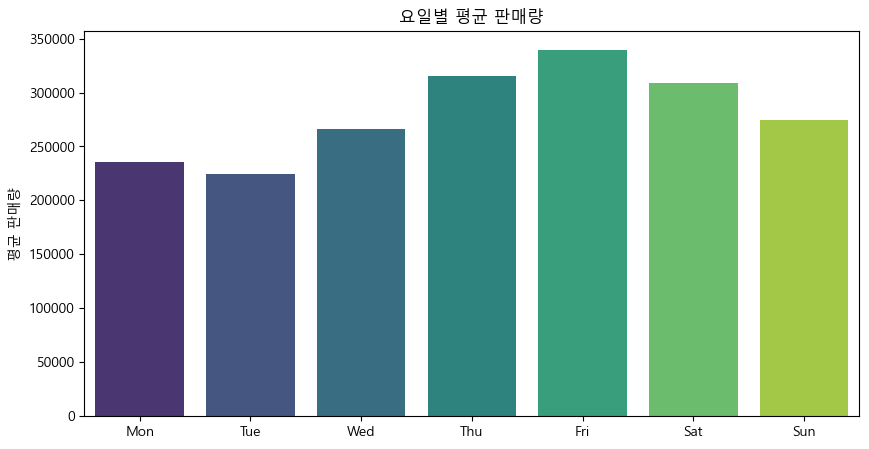

In [8]:
weekday_sales = daily_total_sales.groupby(daily_total_sales.index.dayofweek).mean()
plt.figure(figsize=(10, 5))
sns.barplot(x=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], y=weekday_sales.values, palette='viridis')
plt.title("요일별 평균 판매량")
plt.ylabel("평균 판매량")
plt.show()

전체 제품의 요일별 평균 판매량을 분석한 결과, 금요일에 판매량이 가장 높고 화요일에 가장 낮은 뚜렷한 주간 주기성(Weekly Seasonality)을 확인했습니다. 이는 소비자의 주간 구매 패턴이 존재함을 시사하며, 향후 모델 학습 시 요일 정보(0~6)를 추가 피처로 활용할 수 있을 것 같습니다.

상위 5개 제품 판매량

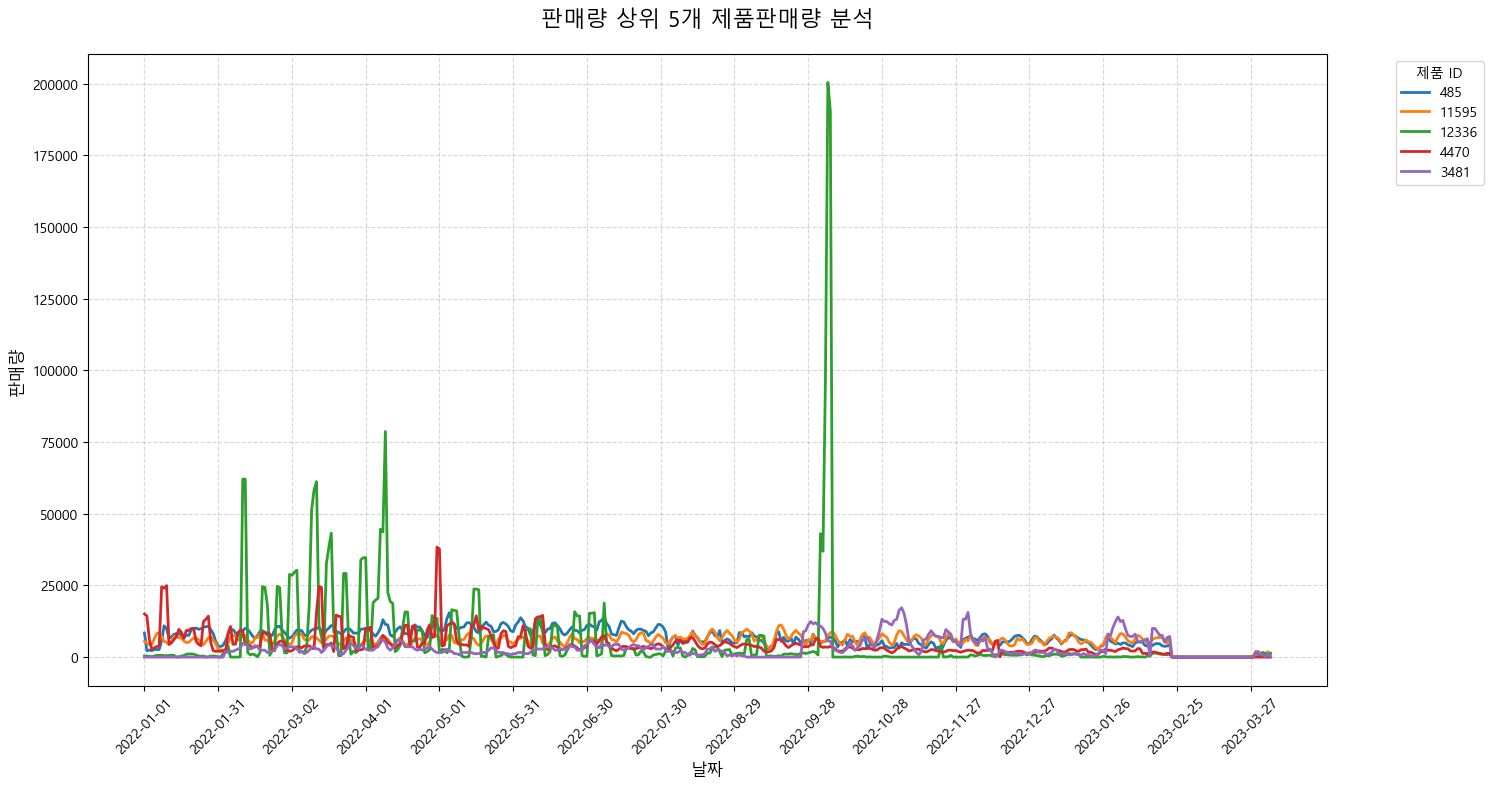

In [9]:
top_5 = train.nlargest(5, 'total_sum').copy()
plt.figure(figsize=(15, 8))
for i, row in top_5.iterrows():
    plt.plot(only_date_cols, row[only_date_cols], label=row['ID'], linewidth=2)
plt.title('판매량 상위 5개 제품판매량 분석', fontsize=16, pad=20)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('판매량', fontsize=12)
plt.xticks(only_date_cols[::30], rotation=45)
plt.legend(title='제품 ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

270일~280일 지점(대략 2022년 10월경)에 초록색 제품(12336)의 판매량이 20만 건까지 어마어마하게 치솟은 게 보입니다. 이건 일반적인 판매가 아니라 역대급 할인 행사나 특정 이슈가 있었을 확률이 높습니다.

### 3.3 검색량-판매량 상관관계 분석

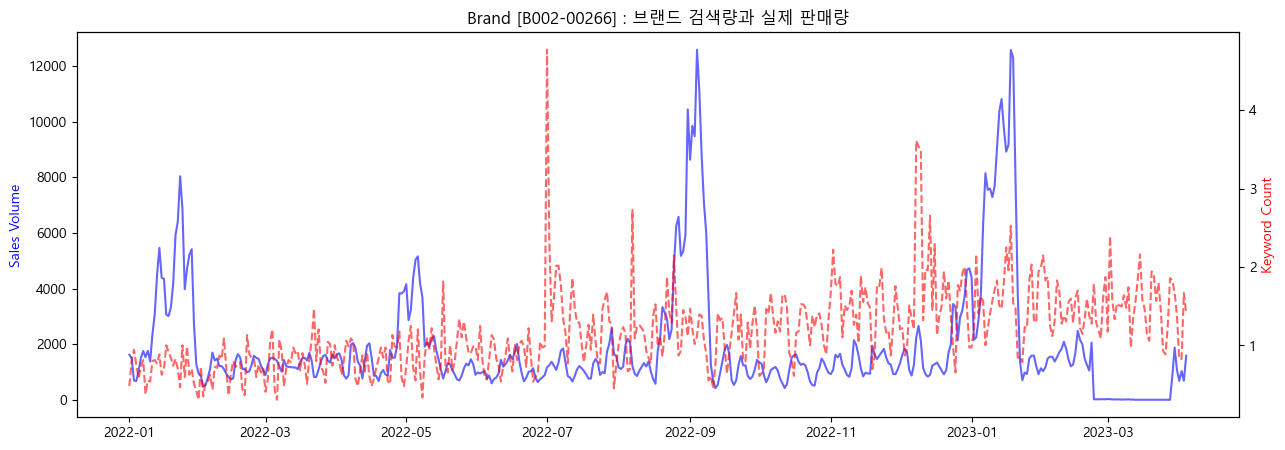

In [11]:
sample_brand = train['브랜드'].value_counts().index[0]
brand_sales_series = train[train['브랜드'] == sample_brand][only_date_cols].sum()
brand_keyword_series = brand_keyword[brand_keyword['브랜드'] == sample_brand][only_date_cols].sum()

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(pd.to_datetime(only_date_cols), brand_sales_series, color='blue', label='Actual Sales', alpha=0.6)
ax1.set_ylabel('Sales Volume', color='blue')
ax2 = ax1.twinx()
ax2.plot(pd.to_datetime(only_date_cols), brand_keyword_series, color='red', linestyle='--', label='Keyword Search Count', alpha=0.6)
ax2.set_ylabel('Keyword Count', color='red')
plt.title(f'Brand [{sample_brand}] : 브랜드 검색량과 실제 판매량')
plt.show()

검색량이 판매량을 '선행'하는 패턴 (신제품/프로모션 효과) : 그래프를 보면 빨간색 점선(검색량)이 먼저 치솟고, 뒤이어 파란색 실선(판매량)이 따라 올라가는 구간이 여러 번 관찰됩니다. 소비자들이 먼저 검색을 통해 정보를 탐색한 뒤, 실제 구매까지는 약간의 시간차가 발생하는 전형적인 구매 결정 과정을 보여줍니다. 모델을 만들 때, 오늘의 검색량뿐만 아니라 어제 혹은 며칠 전의 검색량을 변수(Feature)로 넣어주면 미래 판매량 예측 성능을 높일 수 있을 것 같습니다.<br>
검색량과 판매량의 '동기화' 구간 (강력한 세일) : 2022년 9월이나 2023년 1월경을 보면, 두 선이 거의 동시에 수직 상승합니다. 검색이 발생함과 동시에 즉각적인 구매가 일어나는 현상으로, 보통 강력한 가격 할인 이벤트나 라이브 커머스 같은 행사가 있었을 가능성이 큽니다. 이런 구간은 평소의 완만한 흐름과는 다른 '이벤트 데이터'이므로, 별도의 이벤트 플래그(0 또는 1)를 추가해 모델이 학습하게 해야 오차를 줄일 수 있을 것 같습니다.<br>
'판매 제로' 구간 (2023년 3월 이후) : 가장 눈에 띄는 부분은 그래프 마지막 부분인 2023년 3월부터 판매량이 '0'으로 수렴했다는 점입니다.검색량(빨간 점선)은 여전히 일정 수준 유지되고 있는데, 판매량만 바닥을 치고 있습니다.이는 소비자의 관심은 여전하지만 품절이 되었거나, 해당 채널에서 판매 중단이 되었을 가능성이 높습니다.

### 3.4 미판매 제품

In [12]:
sales_data = train[only_date_cols]
has_sales = (sales_data > 0).any(axis=1)
train['launch_date'] = pd.to_datetime(sales_data.idxmax(axis=1).where(has_sales))

print(f"전체 제품 수: {len(train)}개")
print(f"한 번이라도 판매된 제품: {has_sales.sum()}개")
print(f"판매 기록 전혀 없는 제품: {len(train) - has_sales.sum()}개")

전체 제품 수: 15890개
한 번이라도 판매된 제품: 15805개
판매 기록 전혀 없는 제품: 85개


In [13]:
no_sales_indices = train[~has_sales].index
train_analysis = pd.merge(train, brand_keyword, on='브랜드', how='left', suffixes=('_sales', '_search'))
no_sales_search_data = train_analysis.loc[no_sales_indices].filter(like='_search')
print(no_sales_search_data.sum(axis=1).describe())

count       85.000000
mean      2400.455810
std       5182.620955
min          0.000000
25%         72.031470
50%        307.570481
75%       3222.144074
max      27931.366353
dtype: float64


브랜드 검색량은 평균 2400회로 브랜드가 인지도가 있는 것을 알 수 있고, 85개 중 81개가 검색 기록이 있다는 건, 이 브랜드들이 시장에 노출되어 활동 중이라는 증거입니다. 그런데도 판매 기록이 없다는 건 출시 예정 상품이어서 브랜드 페이지나 상품 상세 페이지는 미리 등록해두어 소비자들이 검색하고 들어오게 유도하지만, 실제 '구매 버튼'은 비활성화해둔 상태일 수 있습니다.
혹은 특정 제품이 원자재 수급 문제나 생산 중단으로 인해 데이터 수집 기간(2022~2023) 내내 '품절' 상태였을 가능성이 있습니다.<br>
판매 기록이 전혀 없는 85개 제품은 모델에게 아무런 패턴도 가르쳐줄 수 없는 노이즈에 가깝기때문에 모델 학습 전처리 단계에서 이 85개 제품은 제거(Drop)해야할 것 같습니다.

### 3.5 Zero-Sales(판매량 0)

In [14]:
zero_count = (train[only_date_cols] == 0).sum().sum()
print(f"전체 대비 0의 비중: {zero_count / train[only_date_cols].size * 100:.2f}%")

전체 대비 0의 비중: 63.79%


0의 비중이 63.79%로 매우 많은 비중을 차지함을 알 수 있습니다.

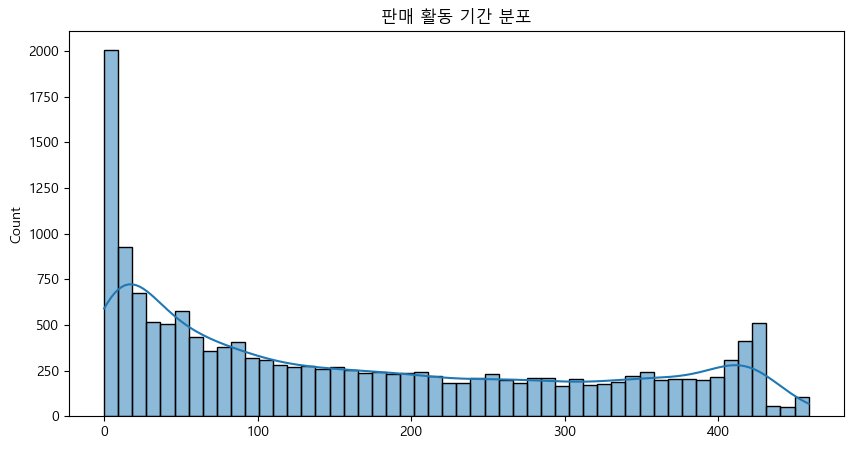

In [15]:
active_days = (train[only_date_cols] > 0).sum(axis=1)
plt.figure(figsize=(10, 5))
sns.histplot(active_days, bins=50, kde=True)
plt.title('판매 활동 기간 분포')
plt.show()

히스토그램에서 왼쪽(0~50일)에 데이터가 몰려 있는 것을 보아 출시 후 금방 판매가 중단되었거나 인기가 없는 제품이 대다수라는 뜻입니다. 반면 오른쪽 끝(400일 이상)에 솟아 있는 데이터는 쇼핑몰을 먹여 살리는 '스테디셀러' 제품들입니다.

전체 데이터 중 판매량이 0인 비율은 63.79%로, 이 데이터셋은 '희소 데이터(Sparse Data)' 특성을 가집니다.<br>

0인 데이터 처리 방법<br>
1. 로그 변환 (Log Transformation) : 0인 데이터는 먼저 로그 변환 해줘야 합니다. 큰 판매량 수치를 압축해서 0과의 격차를 줄여줍니다. 모델이 0의 늪에 빠지지 않고 "작은 변화"를 더 잘 감지하게 됩니다.<br>
2. 이동 평균(Moving Average) 변수 추가 : 단순히 그날의 판매량만 넣지 말고, '최근 7일간 평균 판매량' 같은 변수를 옆에 붙여줍니다. 오늘 판매량이 0이라도 "최근 일주일간은 좀 팔리고 있었다"는 정보를 주면, 모델이 내일 판매량을 예측할 때 훨씬 더 똑똑해집니다.
3. 스케일링 - MinMaxScaler : MinMaxScaler로 스케일링을 해줘서 0과 1 사이로 맞춥니다. 0이 많을 때 가장 무난합니다.

### 3.6 자기상관(ACF) 및 부분자기상관(PACF) 분석

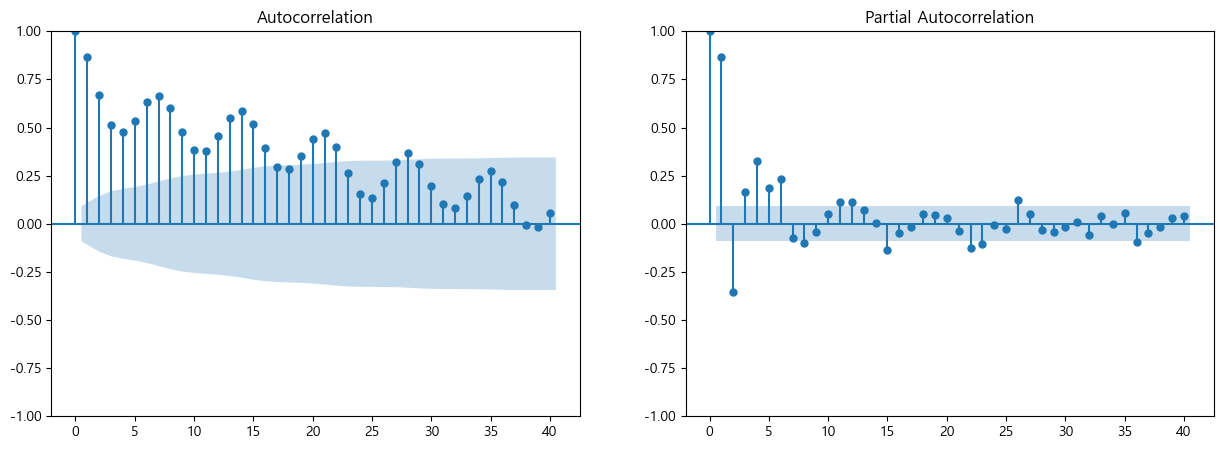

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(daily_total_sales, lags=40, ax=ax[0])
plot_pacf(daily_total_sales, lags=40, ax=ax[1])
plt.show()

- **ACF(자기상관)**: 7일, 14일, 21일 간격으로 높은 상관관계가 반복적으로 나타납니다. 이는 데이터에 매우 뚜렷한 주간 단위(7일 주기) 패턴이 존재함을 의미합니다.
- **PACF(부분 자기상관)**: Lag 1(어제 판매량)에서 가장 높은 상관관계를 보이며, 이후 급격히 감소하다가 7일 지점에서 다시 튀는 모습을 보입니다. 
- **모델링 활용**: 모델이 '7일 전의 데이터'를 중요하게 참고하도록 유도할 필요가 있는 것 같습니다.

### 3.7 검색량-판매량 시차 상관관계 분석 (Cross-Correlation Analysis)

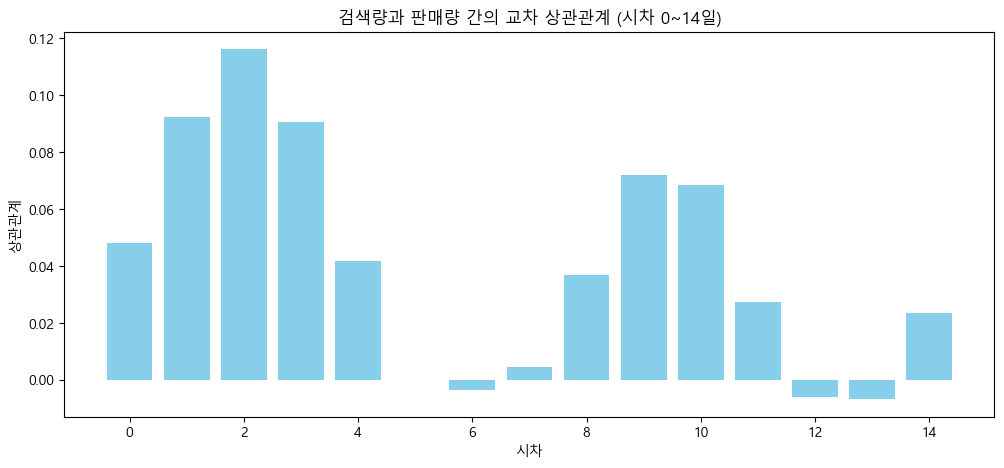

In [17]:
from statsmodels.tsa.stattools import ccf
cross_corr = ccf(brand_sales_series, brand_keyword_series, adjusted=False)
plt.figure(figsize=(12, 5))
plt.bar(range(15), cross_corr[:15], color='skyblue')
plt.title("검색량과 판매량 간의 교차 상관관계 (시차 0~14일)")
plt.xlabel("시차")
plt.ylabel("상관관계")
plt.show()

- 검색량이 발생한 당일(Lag 0)의 상관관계도 높지만, **Lag 1~3 지점**에서 유의미한 상관계수가 유지됩니다.
- **모델링 활용**: 이는 소비자가 검색 후 구매까지 약 1~3일 정도의 고민 기간을 거친다는 것을 뜻합니다. 따라서 특성 공학 단계에서 `search_lag1`,`search_lag2`,  `search_lag3` 변수를 추가하면 예측 성능 향상에 실질적인 도움을 줄 것 같습니다.

### 3.8 이동 통계량 (Rolling Statistics) 분석

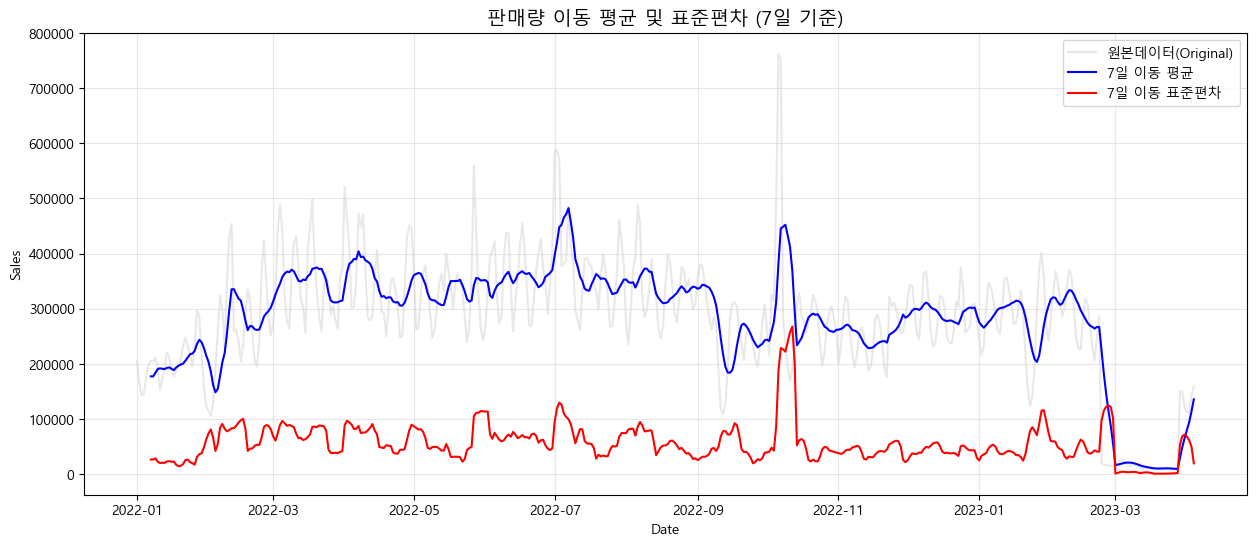

In [18]:
# 이동 통계량 계산 (7일 윈도우)
rolling_mean = daily_total_sales.rolling(window=7).mean()
rolling_std = daily_total_sales.rolling(window=7).std()

plt.figure(figsize=(15, 6))
plt.plot(daily_total_sales, color='lightgray', alpha=0.5, label='원본데이터(Original)')
plt.plot(rolling_mean, color='blue', label='7일 이동 평균')
plt.plot(rolling_std, color='red', label='7일 이동 표준편차')
plt.title("판매량 이동 평균 및 표준편차 (7일 기준)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- Rolling Mean (추세 파악): 원본 데이터의 불규칙한 노이즈를 제거하여 전반적인 판매 트렌드를 가시화했습니다. 2022년 하반기부터 완만한 상승 곡선을 그리다 2023년 초 급격히 하락하는 추세를 명확히 확인할 수 있으며, 이는 모델이 학습해야 할 핵심 거시 트렌드입니다.

- Rolling Std (변동성 감지): 특정 구간(명절 전후, 프로모션 등)에서 빨간색 선이 급격히 솟구치는 지점은 판매 변동성이 극대화되는 구간입니다. 이러한 변동성이 큰 구간은 예측 오차가 발생하기 쉬우므로 별도의 관리가 필요함을 시사합니다.

- 모델링 활용 전략 (Feature Engineering): 1.  단일 시점의 수치 대신 '최근 7일간의 이동 평균'을 피처로 추가하여 모델이 단기 노이즈에 휘둘리지 않고 안정적인 추세를 추종하도록 유도합니다.
2.  이동 표준편차를 피처로 활용하여, 현재 시장 상황이 안정적인지 아니면 급변하는 중인지에 대한 '상태 정보'를 모델에게 제공합니다.

### 3.9 대분류별 시즌성 히트맵

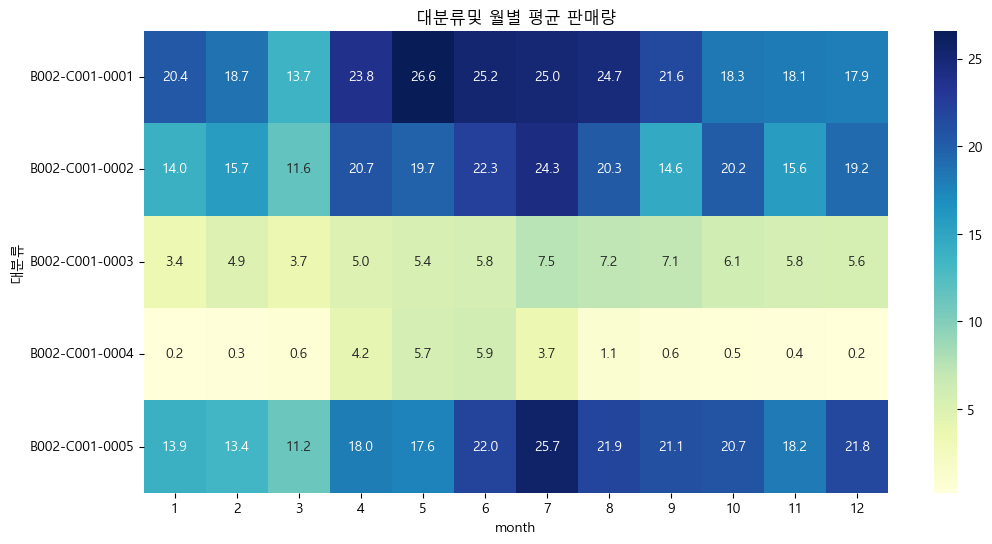

In [19]:
train_melted = train.melt(id_vars=['대분류'], value_vars=only_date_cols, var_name='date', value_name='sales')
train_melted['month'] = pd.to_datetime(train_melted['date']).dt.month
pivot = train_melted.pivot_table(index='대분류', columns='month', values='sales', aggfunc='mean')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='.1f')
plt.title("대분류및 월별 평균 판매량")
plt.show()

- 특정 카테고리는 여름(7-8월)에 압도적으로 판매가 높고, 다른 카테고리는 연말에 반등하는 등 **카테고리별 시즌성**이 다르게 나타납니다.
- **모델링 활용**: 모든 제품을 하나의 모델로 학습시키기보다는, 입력 데이터에 카테고리 정보(대분류)를 강력하게 반영해야 카테고리 특유의 시즌성을 모델이 학습할 수 있습니다.

### 3.10 한국 주요 공휴일 분석

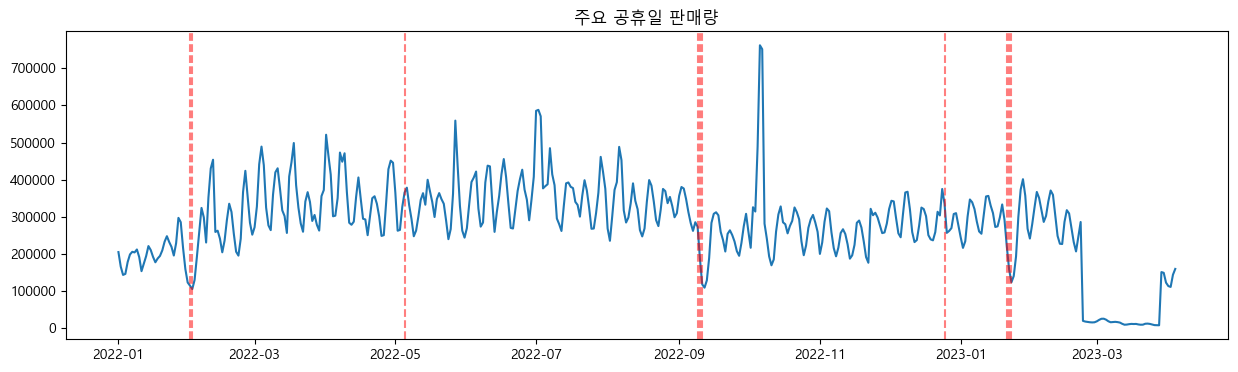

In [20]:
holidays = pd.to_datetime(['2022-02-01', '2022-02-02', '2022-05-05', '2022-09-09', '2022-09-10', '2022-09-11', '2022-12-25', '2023-01-21', '2023-01-22', '2023-01-23'])
plt.figure(figsize=(15, 4))
plt.plot(daily_total_sales)
for h in holidays:
    if h in daily_total_sales.index: plt.axvline(h, color='red', alpha=0.5, linestyle='--')
plt.title("주요 공휴일 판매량")
plt.show()

- 공휴일 전후(설날, 추석)로 판매량이 급변하는 패턴이 관찰됩니다.<br>1.연휴로 판매량이 꺾이기 직전(약 3~7일 전)을 보면 평소보다 판매량이 위로 튀는 **스파이크(Spike)**가 관찰됩니다. 명절 선물을 미리 준비하거나, 연휴 동안 배송이 안 될 것을 대비해 생필품을 미리 사두려는 사전 구매 수요가 몰리기 때문으로 보입니다.<br>2. 빨간 점선(공휴일)이 시작되는 시점부터 판매량이 바닥을 치는 V자형 골짜기가 형성됩니다(2022년 추석(9월)과 2023년 설날(1월)). 이는 소비자가 구매를 안 해서라기보다, 온라인 쇼핑몰 특성상 택배 배송이 중단되기 때문에 발생하는 현상으로 보입니다.

- **모델링 활용**: 1.  공휴일 피처(Holiday): 예측 시점의 날짜가 공휴일인지 여부를 Binary(0 또는 1) 피처로 추가합니다.<br>2. D-Day 피처: "명절 전 3~5일" 구간을 별도의 변수로 만들어 판매량 급증 패턴을 학습시킵니다.<br>3. 배송 불가능 구간 피처: 연휴 당일뿐만 아니라 택배사가 쉬는 전후 기간을 '배송 불가능 기간'으로 정의하여 모델이 이 시기의 낮은 판매량을 "제품의 인기 하락"으로 오해하지 않게 합니다.

### 3.11 시계열 분해 분석

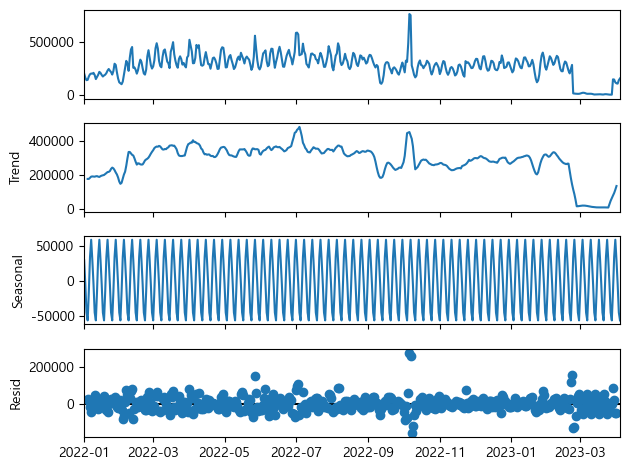

In [21]:
decomposition = seasonal_decompose(daily_total_sales, model='additive', period=7)
decomposition.plot()
plt.show()

Trend (추세): 전체적인 판매량의 흐름입니다. 2022년 7월경 정점을 찍고 내려왔다가 10월에 다시 튀는 모습을 보입니다.<br>
Seasonal (계절성): 규칙적인 파동입니다. 아주 일정한 간격으로 오르내리는 걸 보니 요일별 패턴이 매우 뚜렷하다는 것을 알 수 있습니다.<br>
Resid (잔차): 추세나 계절성으로 설명되지 않는 '돌발 변수'입니다. 2022년 10월경에 점들이 위로 크게 튀어 있습니다. 위에 그래프에서 확인한 이상치로 볼 수 있습니다.

### 3.12 시계열 정상성(Stationarity) 분석 (ADF Test)
데이터가 통계적으로 일정한 패턴(평균, 분산)을 유지하는지 확인하여 시계열 모델링의 안정성을 검토합니다.

In [22]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series):
    # ADF Test 수행
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    
    # 결과 해석
    if result[1] <= 0.05:
        print("데이터가 정상성을 띠고 있습니다. (귀무가설 기각: Stationary)")
    else:
        print("데이터가 비정상성을 띠고 있습니다. (귀무가설 채택: Non-Stationary)")
        print("추세나 계절성 제거를 위해 차분이 필요할 수 있습니다.")

print("--- [Original Series] ---")
check_stationarity(daily_total_sales)

print("\n--- [1st Order Differenced Series] ---")
check_stationarity(daily_total_sales.diff().dropna())


--- [Original Series] ---
ADF Statistic: -1.8483
p-value: 0.3568
데이터가 비정상성을 띠고 있습니다. (귀무가설 채택: Non-Stationary)
추세나 계절성 제거를 위해 차분이 필요할 수 있습니다.

--- [1st Order Differenced Series] ---
ADF Statistic: -7.5020
p-value: 0.0000
데이터가 정상성을 띠고 있습니다. (귀무가설 기각: Stationary)


- ADF Test 결과: 원본 데이터의 p-value가 0.3568로 나타나 비정상성(Non-stationary)을 띠는 것으로 확인되었습니다. 이는 데이터에 시간의 흐름에 따른 평균이나 분산의 변화(추세)가 포함되어 있음을 의미하며, 이대로 학습할 경우 모델이 특정 추세에 과적합(Overfitting)될 위험이 있습니다.
- 데이터 처리: 1차 차분(Differencing)을 수행한 결과, p-value가 0.0000으로 떨어지며 통계적 정상성(Stationarity)을 확보했습니다.
- 모델링 활용 전략: 1. 차분 데이터 활용: 모델 학습 시 원본값 대신 변동폭(차분값)을 입력값으로 사용하여 추세에 의한 왜곡을 방지합니다.
2. 구조적 보완: 모델이 현재 데이터의 강한 주기성(7일 단위 등)을 잘 포착할 수 있도록 Window Size(과거 참조 기간)를 충분히 설정하고, 필요시 추세를 별도로 학습하는 구조를 검토해야할 것 같습니다.

## 4. 데이터 전처리 (Preprocessing)


**극심한 우편향 데이터 완화: 로그 변환 (Log Transformation)**
판매량이 0인 날이 64%에 달하며 특정 날에는 20만 건까지 치솟는 극단적인 분포를 보입니다. 딥러닝 모델은 거대 이상치에 과도하게 반응하여 평소의 완만한 판매 흐름을 무시하고 오차가 커질 수 있습니다.<br>
`np.log1p()` 함수를 사용하여 판매량에 1을 더한 후 로그를 취해 스케일을 압축합니다.

**'미판매' 제품 제거 및 희소성 처리 (Data Cleaning)**
판매 기록이 전혀 없는 85개 제품은 모델에게 어떤 패턴도 줄 수 없는 '순수 노이즈'입니다. 출시 전의 0 데이터는 시스템적 0이므로 모델이 이를 '인기 없음'으로 오해하지 않게 해야 합니다.<br>
판매 기록이 전혀 없는 행은 삭제하고, 실제 판매가 시작된 지점부터 학습에 비중을 둡니다.

In [23]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# 미판매 제품 제거
train_cleaned = train[has_sales].reset_index(drop=True)

# 로그 변환
train_cleaned[only_date_cols] = np.log1p(train_cleaned[only_date_cols])

# 범주형 변수 인코딩
le = LabelEncoder()
for col in ['대분류', '중분류', '소분류', '브랜드']:
    train_cleaned[col] = le.fit_transform(train_cleaned[col])

# 스케일링
scaler = MinMaxScaler()
all_sales_values = train_cleaned[only_date_cols].values.reshape(-1, 1)
scaler.fit(all_sales_values)

# 학습된 기준으로 전체 데이터 변환
scaled_values = scaler.transform(all_sales_values).reshape(train_cleaned[only_date_cols].shape)
train_cleaned[only_date_cols] = scaled_values

print("Preprocessing Completed.")

Preprocessing Completed.


## 5. 특성 공학 (Feature Engineering)

시계열 예측력을 극대화하기 위해 다변량(Multivariate) 피처를 생성합니다.

**시차 변수 생성 (Lag Features)**
CCF(교차 상관 분석) 결과, 검색량이 판매량보다 1~3일 앞선다는 사실을 확인했습니다. '3일 전 검색량'이 늘었다는 정보는 모델에게 곧 판매량이 늘어날 것이라는 강력한 힌트가 됩니다.<br>
브랜드 검색량 데이터를 1일, 2일, 3일씩 뒤로 밀어낸 컬럼을 생성하여 피처로 넣습니다.

**공휴일 및 명절 플래그 (Holiday Encoding)**
공휴일 전후로 판매량이 급변(V자형 골짜기)하는 것을 확인했습니다. 모델이 이를 단순히 수요 감소로 판단하지 않도록 특수한 시기임을 알려줘야 합니다.<br>
예측하려는 날짜가 명절 연휴(설날, 추석)인지를 0과 1로 구분하는 변수를 추가합니다.

**이동 평균 피처 (Rolling Mean)**
시계열 데이터는 매일의 수치보다 '최근 일주일간의 추세'가 미래 예측에 더 중요합니다. 최근 7일간의 평균을 함께 주면 모델이 추세를 훨씬 안정적으로 따라갑니다.<br>
`rolling(window=7).mean()`을 사용하여 최근 일주일 평균 판매량을 계산해 피처로 활용합니다.

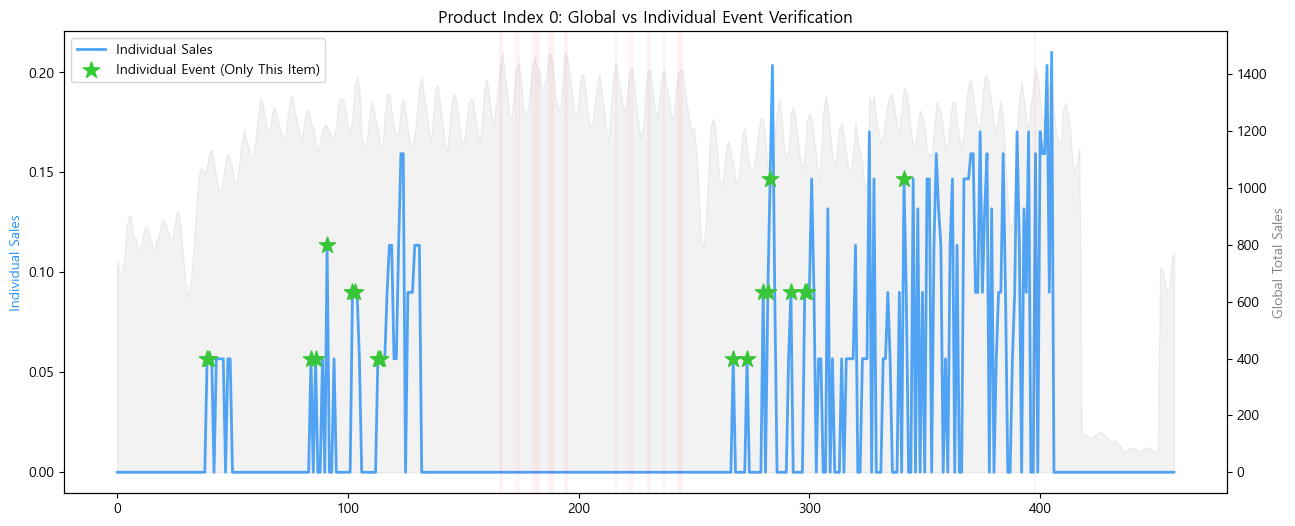

결과 보고:
- 전체가 다 같이 튀는 날(Global): 23일
- 이 제품만 독자적으로 튀는 날(Individual): 18일


In [32]:
import matplotlib.pyplot as plt

def verify_individual_events(product_idx, threshold=3):
    # 1. 개별 제품 판매량 및 전체 판매량 합계 준비
    sales = train_cleaned[only_date_cols].iloc[product_idx].values
    global_total = train_cleaned[only_date_cols].sum().values
    
    # 2. 전체 이벤트(Global)와 개별 급증(Spike) 정의
    # 전체 상위 5%를 글로벌 이벤트로 가정
    is_global_event = (global_total > np.percentile(global_total, 95))
    
    # 개별 제품이 7일 이동평균보다 threshold배 높은 지점
    individual_spike = (sales > (pd.Series(sales).rolling(7, min_periods=1).mean() * threshold))
    
    # [핵심] 전체는 조용한데(global=0) 혼자 튀는 날(spike=1)을 개별 이벤트로 추출
    is_individual_event = individual_spike & (~is_global_event)
    
    # 3. 시각화
    fig, ax1 = plt.subplots(figsize=(15, 6))
    
    # 왼쪽 축: 개별 제품 판매량
    ax1.plot(sales, label='Individual Sales', color='dodgerblue', alpha=0.8, linewidth=2)
    ax1.set_ylabel('Individual Sales', color='dodgerblue')
    
    # 오른쪽 축: 전체 판매량 흐름 (배경)
    ax2 = ax1.twinx()
    ax2.fill_between(range(len(global_total)), 0, global_total, color='gray', alpha=0.1, label='Global Total Sales')
    ax2.set_ylabel('Global Total Sales', color='gray')
    
    # 개별 이벤트 지점 표시 (초록색 별표)
    event_days = np.where(is_individual_event)[0]
    ax1.scatter(event_days, sales[event_days], color='limegreen', marker='*', s=150, 
                label='Individual Event (Only This Item)', zorder=5)
    
    # 글로벌 이벤트 지점 표시 (빨간색 투명 세로선)
    global_event_days = np.where(is_global_event)[0]
    for d in global_event_days:
        ax1.axvline(d, color='red', alpha=0.05)

    plt.title(f"Product Index {product_idx}: Global vs Individual Event Verification")
    ax1.legend(loc='upper left')
    plt.show()

    print(f"결과 보고:")
    print(f"- 전체가 다 같이 튀는 날(Global): {is_global_event.sum()}일")
    print(f"- 이 제품만 독자적으로 튀는 날(Individual): {is_individual_event.sum()}일")

# 몇 가지 샘플 확인
verify_individual_events(product_idx=0)

In [38]:
def get_event_dates(product_idx, threshold=3):
    # 1. 날짜 정보 및 판매량 준비
    dates = pd.to_datetime(only_date_cols)
    sales = train_cleaned[only_date_cols].iloc[product_idx].values
    global_total = train_cleaned[only_date_cols].sum().values
    
    # 2. 글로벌/개별 이벤트 조건 정의
    is_global_event = (global_total > np.percentile(global_total, 95))
    individual_spike = (sales > (pd.Series(sales).rolling(7, min_periods=1).mean() * threshold))
    
    # 3. 날짜 분류
    # A. 전체 시장과 함께 튄 날 (Global + Individual Spike)
    market_wide_dates = dates[is_global_event & individual_spike]
    
    # B. 시장은 조용한데 이 제품만 튄 날 (Only Individual)
    pure_individual_dates = dates[(~is_global_event) & individual_spike]
    
    # 4. 결과 출력
    print(f"--- [Index {product_idx}] 제품 이벤트 분석 결과 ---")
    
    print(f"\n✅ [시장 공통 급증일] 총 {len(market_wide_dates)}일")
    if len(market_wide_dates) > 0:
        for d in market_wide_dates:
            print(f" - {d.strftime('%Y-%m-%d')} (전체 시장 트렌드와 일치)")
    else:
        print(" - 해당 사항 없음")
            
    print(f"\n⭐️ [제품 독자 급증일] 총 {len(pure_individual_dates)}일")
    if len(pure_individual_dates) > 0:
        for d in pure_individual_dates:
            print(f" - {d.strftime('%Y-%m-%d')} (이 제품만의 단독 이벤트 추정)")
    else:
        print(" - 해당 사항 없음")

# 예시: 아까 그 제품(0번 혹은 확인하고 싶은 번호)의 날짜 확인
get_event_dates(product_idx=4)

--- [Index 4] 제품 이벤트 분석 결과 ---

✅ [시장 공통 급증일] 총 1일
 - 2023-02-03 (전체 시장 트렌드와 일치)

⭐️ [제품 독자 급증일] 총 18일
 - 2022-01-25 (이 제품만의 단독 이벤트 추정)
 - 2022-01-26 (이 제품만의 단독 이벤트 추정)
 - 2022-02-04 (이 제품만의 단독 이벤트 추정)
 - 2022-02-05 (이 제품만의 단독 이벤트 추정)
 - 2022-02-15 (이 제품만의 단독 이벤트 추정)
 - 2022-02-16 (이 제품만의 단독 이벤트 추정)
 - 2022-02-23 (이 제품만의 단독 이벤트 추정)
 - 2022-02-24 (이 제품만의 단독 이벤트 추정)
 - 2022-04-15 (이 제품만의 단독 이벤트 추정)
 - 2022-10-10 (이 제품만의 단독 이벤트 추정)
 - 2022-10-13 (이 제품만의 단독 이벤트 추정)
 - 2022-12-20 (이 제품만의 단독 이벤트 추정)
 - 2022-12-28 (이 제품만의 단독 이벤트 추정)
 - 2023-01-14 (이 제품만의 단독 이벤트 추정)
 - 2023-01-24 (이 제품만의 단독 이벤트 추정)
 - 2023-01-25 (이 제품만의 단독 이벤트 추정)
 - 2023-02-05 (이 제품만의 단독 이벤트 추정)
 - 2023-02-11 (이 제품만의 단독 이벤트 추정)


--- 전체 제품(1000개 샘플) 이벤트 성향 분석 ---
평균 시장 공통 급증일: 0.61일
평균 제품 독자 급증일: 8.57일


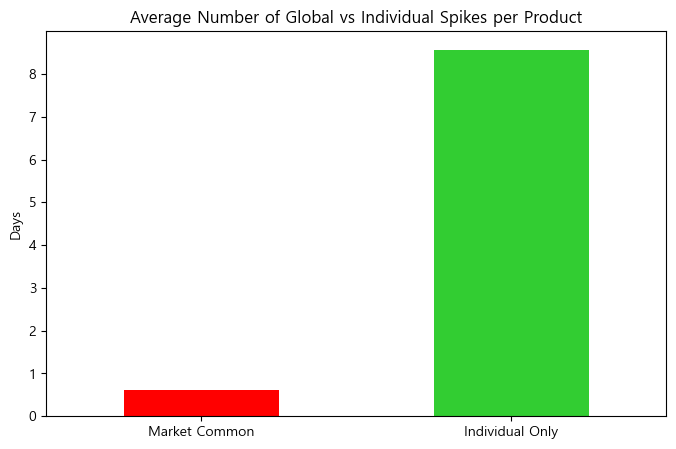

In [39]:
def summarize_event_types(df, n_samples=1000): # 너무 많으면 시간이 걸리니 1000개만 샘플링
    global_total = df[only_date_cols].sum().values
    is_global_event = (global_total > np.percentile(global_total, 95))
    
    results = []
    
    # 상위 n_samples개 제품에 대해 루프
    for i in range(min(n_samples, len(df))):
        sales = df[only_date_cols].iloc[i].values
        individual_spike = (sales > (pd.Series(sales).rolling(7, min_periods=1).mean() * 3))
        
        # 1. 시장 공통 급증 (Global & Spike)
        common_count = (is_global_event & individual_spike).sum()
        # 2. 독자적 급증 (Individual Only)
        pure_indiv_count = ((~is_global_event) & individual_spike).sum()
        
        results.append({
            'common': common_count,
            'individual': pure_indiv_count
        })
    
    res_df = pd.DataFrame(results)
    
    print(f"--- 전체 제품({n_samples}개 샘플) 이벤트 성향 분석 ---")
    print(f"평균 시장 공통 급증일: {res_df['common'].mean():.2f}일")
    print(f"평균 제품 독자 급증일: {res_df['individual'].mean():.2f}일")
    
    # 시각화
    res_df.mean().plot(kind='bar', color=['red', 'limegreen'], figsize=(8, 5))
    plt.title("Average Number of Global vs Individual Spikes per Product")
    plt.ylabel("Days")
    plt.xticks(ticks=[0, 1], labels=['Market Common', 'Individual Only'], rotation=0)
    plt.show()

summarize_event_types(train_cleaned)

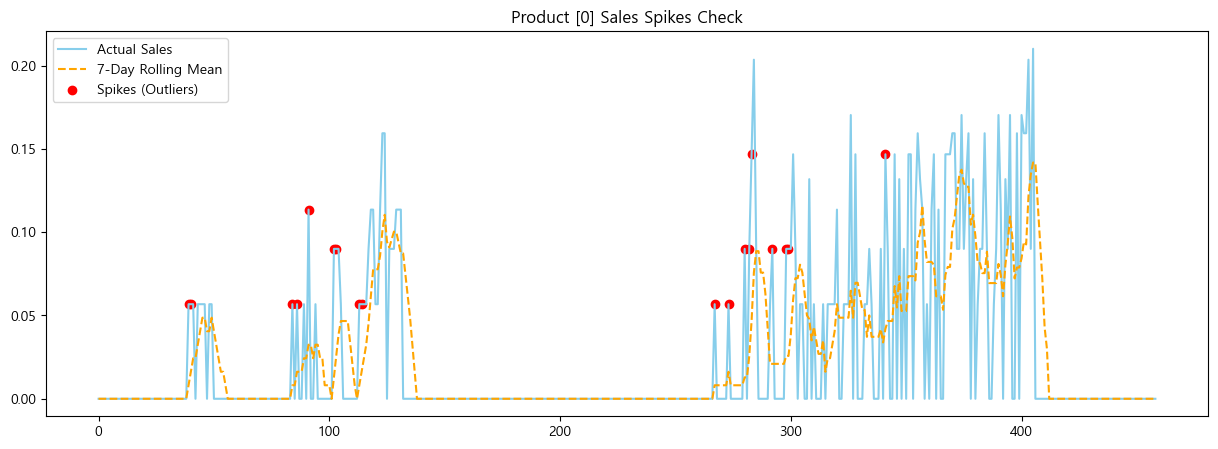

총 459일 중 18일이 평소보다 3배 이상 많이 팔렸습니다.


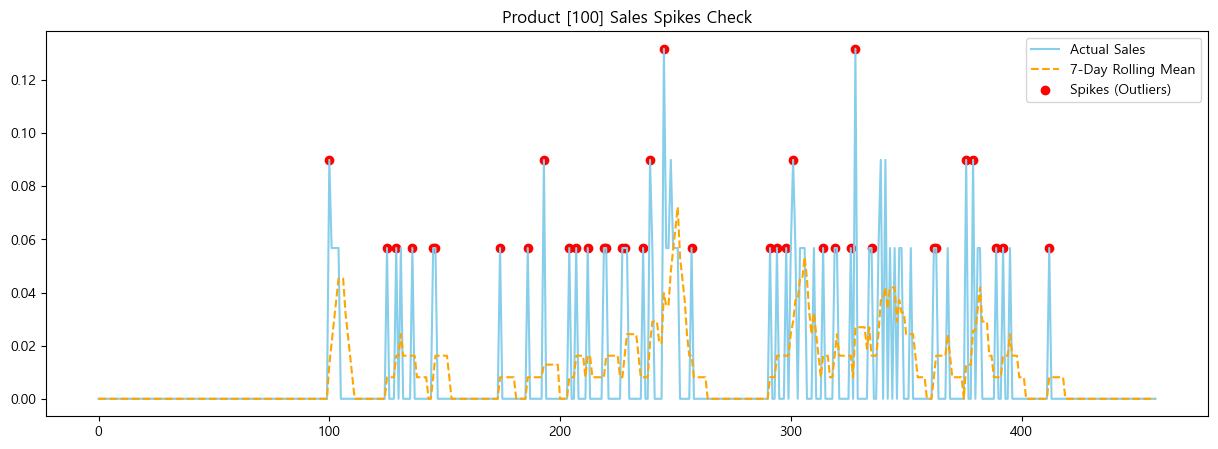

총 459일 중 36일이 평소보다 3배 이상 많이 팔렸습니다.


In [31]:
import matplotlib.pyplot as plt

def check_individual_spikes(product_idx, threshold=3):
    sales = train_cleaned.iloc[product_idx][only_date_cols].values
    
    # 7일 이동 평균 계산 (평소 판매량의 기준)
    rolling_mean = pd.Series(sales).rolling(window=7, min_periods=1).mean()
    
    # 평소(이동평균)보다 threshold배 이상 튄 날 찾기
    spike_days = sales > (rolling_mean * threshold)
    
    # 시각화
    plt.figure(figsize=(15, 5))
    plt.plot(sales, label='Actual Sales', color='skyblue')
    plt.plot(rolling_mean, label='7-Day Rolling Mean', color='orange', linestyle='--')
    plt.scatter(np.where(spike_days)[0], sales[spike_days], color='red', label='Spikes (Outliers)')
    
    product_id = train_cleaned.iloc[product_idx]['ID']
    plt.title(f"Product [{product_id}] Sales Spikes Check")
    plt.legend()
    plt.show()
    
    print(f"총 {len(sales)}일 중 {spike_days.sum()}일이 평소보다 {threshold}배 이상 많이 팔렸습니다.")

# 랜덤하게 몇 개 제품 테스트
check_individual_spikes(0) 
check_individual_spikes(100)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 공휴일 리스트 정의 및 플래그 생성
holidays = pd.to_datetime([
    '2022-02-01', '2022-02-02', '2022-05-05', '2022-09-09', 
    '2022-09-10', '2022-09-11', '2022-12-25', '2023-01-21', 
    '2023-01-22', '2023-01-23'
])
is_holiday = np.array([1 if pd.to_datetime(date) in holidays else 0 for date in only_date_cols])

# 글로벌 이벤트 플래그 생성 (전체 상위 5%)
daily_total = train_cleaned[only_date_cols].sum()
is_global_event = (daily_total > daily_total.quantile(0.95)).astype(int).values

def prepare_multivariate_data(product_idx, window_size=28):
    brand_name = train_cleaned.iloc[product_idx]['브랜드']
    # 윈도우 인코딩을 위해 LabelEncoder 역변환 필요 시 활용
    brand_orig = le.inverse_transform([brand_name])[0] if '브랜드' in train_cleaned.columns else brand_name
    
    # --- 타겟 데이터 및 이동 통계량 ---
    sales_series = scaled_sales[product_idx]
    sales_pd = pd.Series(sales_series)
    
    roll_mean = sales_pd.rolling(window=7, min_periods=1).mean().fillna(0).values
    roll_std = sales_pd.rolling(window=7, min_periods=1).std().fillna(0).values # 변동성 피처 추가!
    
    # --- 개별 제품 독자 이벤트 ---
    # 판매량이 이동평균의 3배 이상이면서, 글로벌 이벤트가 아닌 날
    individual_spike = (sales_series > (roll_mean * 3))
    is_individual_event = (individual_spike & (~is_global_event.astype(bool))).astype(int)
    
    # --- 검색량 시차 변수 ---
    brand_search = brand_keyword[brand_keyword['브랜드'] == brand_orig][only_date_cols].values.flatten()
    if len(brand_search) == 0: 
        brand_search = np.zeros(len(only_date_cols))
        
    # 검색량도 폭증하는 날이 있으므로 로그 변환 후 스케일링
    search_log = np.log1p(brand_search)
    search_scaled = MinMaxScaler().fit_transform(search_log.reshape(-1, 1)).flatten()
    
    search_pd = pd.Series(search_scaled)
    # np.roll 대신 shift를 사용하여 미래 데이터가 과거로 오는 것을 방지
    s_lag1 = search_pd.shift(1).fillna(0).values
    s_lag2 = search_pd.shift(2).fillna(0).values
    s_lag3 = search_pd.shift(3).fillna(0).values
    
    # --- 데이터 결합 (총 9개 피처) ---
    combined = np.stack([
        sales_series,         # 0: Target
        is_holiday,           # 1: 공휴일 하락 방어
        is_global_event,      # 2: 대형 세일 (0.61일)
        is_individual_event,  # 3: 독자 프로모션 (8.57일) - 핵심!
        s_lag1, s_lag2, s_lag3, # 4, 5, 6: 검색 선행 지표
        roll_mean, roll_std   # 7, 8: 추세 및 변동성
    ], axis=1)
    
    X, y = [], []
    for i in range(window_size, len(combined)):
        X.append(combined[i-window_size:i])
        y.append(combined[i, 0])
        
    return np.array(X), np.array(y)

X_final, y_final = prepare_multivariate_data(0)
print(f"최종 피처 구성 완료: {X_final.shape[2]}개 피처 사용 중 (X shape: {X_final.shape})")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 공휴일 리스트 정의 및 플래그 생성
holidays = pd.to_datetime([
    '2022-02-01', '2022-02-02', '2022-05-05', '2022-09-09', 
    '2022-09-10', '2022-09-11', '2022-12-25', '2023-01-21', 
    '2023-01-22', '2023-01-23'
])
is_holiday = np.array([1 if pd.to_datetime(date) in holidays else 0 for date in only_date_cols])

# 글로벌 이벤트 플래그 생성(상위 5%)
daily_total = train_cleaned[only_date_cols].sum()
is_global_event = (daily_total > daily_total.quantile(0.95)).astype(int).values

# 요일 및 주말 변수
dates_dt = pd.to_datetime(only_date_cols)
is_weekend = ((dates_dt.dayofweek == 5) | (dates_dt.dayofweek == 6)).astype(int).values
day_of_week_scaled = (dates_dt.dayofweek / 6.0).values

# 개별 제품 데이터 전처리 함수
def prepare_multivariate_data(product_idx, window_size=28):
    brand_name = train_cleaned.iloc[product_idx]['브랜드']
    brand_orig = le.inverse_transform([brand_name])[0] if '브랜드' in train_cleaned.columns else brand_name
    
    # 타겟 데이터 및 이동 통계량
    sales_series = scaled_sales[product_idx]
    sales_pd = pd.Series(sales_series)
    roll_mean = sales_pd.rolling(window=7, min_periods=1).mean().fillna(0).values
    roll_std = sales_pd.rolling(window=7, min_periods=1).std().fillna(0).values
    
    # 개별 제품 독자 이벤트 (판매량이 이동평균의 3배 이상이면서, 글로벌 이벤트가 아닌 날)
    individual_spike = (sales_series > (roll_mean * 3))
    is_individual_event = (individual_spike & (~is_global_event.astype(bool))).astype(int)

    # 검색량 시차 변수 (데이터 누수 방지를 위해 shift 사용)
    brand_search = brand_keyword[brand_keyword['브랜드'] == brand_orig][only_date_cols].values.flatten()
    if len(brand_search) == 0: 
        brand_search = np.zeros(len(only_date_cols))
        
    search_log = np.log1p(brand_search)
    search_scaled = MinMaxScaler().fit_transform(search_log.reshape(-1, 1)).flatten()
    search_pd = pd.Series(search_scaled)
    
    s_lag1 = search_pd.shift(1).fillna(0).values
    s_lag2 = search_pd.shift(2).fillna(0).values
    s_lag3 = search_pd.shift(3).fillna(0).values
    
    # 데이터 결합 (총 11개 피처)
    combined = np.stack([
        sales_series,         # 0: Target
        is_holiday,           # 1: 공휴일
        is_global_event,      # 2: 대형 세일
        is_individual_event,  # 3: 독자 프로모션
        is_weekend,           # 4: 주말 여부
        day_of_week_scaled,   # 5: 요일 패턴
        s_lag1, s_lag2, s_lag3, # 6, 7, 8: 검색 선행 지표
        roll_mean, roll_std   # 9, 10: 추세, 변동성
    ], axis=1)
    
    X, y = [], []
    for i in range(window_size, len(combined)):
        X.append(combined[i-window_size:i])
        y.append(combined[i, 0])
        
    return np.array(X), np.array(y)

# 테스트 실행
X_final, y_final = prepare_multivariate_data(0)
print(f"최종 피처 구성 완료: {X_final.shape[2]}개 피처 사용 중 (X shape: {X_final.shape})")

## 6. 모델링 (Multivariate GRU)

In [ ]:
model = Sequential([
    GRU(128, input_shape=(28, X.shape[2]), return_sequences=True),
    Dropout(0.2),
    GRU(64),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='huber')
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X, y, epochs=100, batch_size=32, validation_split=0.2, callbacks=[es], verbose=1)